# bigspy — Bayesian Inference of Galaxy Spectra

Two-stage spectral fitting pipeline:
1. **SpecFit** — PCA fitting for kinematics ($v_e$, $v_d$) and dust attenuation
2. **MCMC** — UltraNest Bayesian inference of stellar population parameters

In [33]:
import os, sys, time, numpy as np
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from bigspy.specfit import load_test_spectrum
from bigspy import SpecFit, MCMCFitter
from bigspy.mcmc.sfh import SFHBase, DelayedExponentialSFH
from bigspy.mcmc.priors import UniformPrior, LogUniformPrior, FixedPrior

print('All imports OK')

All imports OK


## 1. Data Paths

In [34]:
REPO = os.path.abspath('..')
PCA_FILE  = os.path.join(REPO, 'template', 'BC03_Padova1994_chab_PCA_extend_new.fits')
SSP_FILE  = os.path.join(REPO, 'template', 'SSP_BC03_Padova1994_chab.fits')
TEST_FILE = os.path.join(REPO, 'tests', 'manga-7443-12703-28-28.pkl')
#TEST_FILE = os.path.join(REPO, 'tests', 'manga-8131-6102-28-28.pkl')
OUT_DIR   = os.path.join(REPO, 'out_notebook')
os.makedirs(OUT_DIR, exist_ok=True)

for f in [PCA_FILE, SSP_FILE, TEST_FILE]:
    assert os.path.exists(f), f'Missing: {f}'
print('All data files found')

All data files found


## 2. Load Observed Spectrum

Redshift           z = 0.0403
Pixels               = 4563
Wavelength range     = 3622 – 10354 Å
Dispersion (DAP)     = 88 km/s


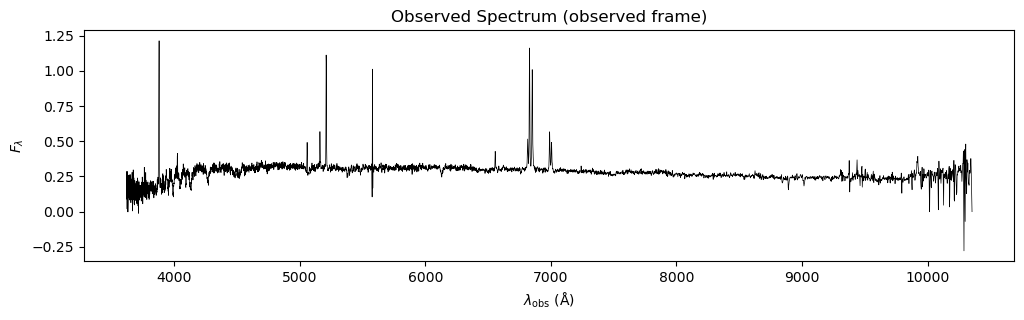

In [35]:
data = load_test_spectrum(TEST_FILE)
print(f'Redshift           z = {data["z"]:.4f}')
print(f'Pixels               = {len(data["wave_obs"])}')
print(f'Wavelength range     = {data["wave_obs"][0]:.0f} – {data["wave_obs"][-1]:.0f} Å')
print(f'Dispersion (DAP)     = {data["sigma_dap"]:.0f} km/s')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(data['wave_obs'], data['flux_obs'], 'k-', lw=0.5)
ax.set_xlabel(r'$\lambda_{\rm obs}\ (\mathrm{\AA})$')
ax.set_ylabel(r'$F_\lambda$')
ax.set_title('Observed Spectrum (observed frame)')
plt.show()

## 3. SpecFit — Kinematics + Dust

In [36]:
%%time
sf = SpecFit(PCA_FILE)
specfit = sf.fit(
    wave=data['wave_obs'], flux=data['flux_obs'],
    error=data['error_obs'], mask=data['mask_obs'],
    z_sys=data['z'], mode='mode2',
)

print(f'v_e   = {specfit.ve[0]:8.1f}  ± {specfit.ve[1]:5.1f}  km/s')
print(f'v_d   = {specfit.vd[0]:8.1f}  ± {specfit.vd[1]:5.1f}  km/s')
print(f'E(B-V) = {specfit.ebv[0]:6.4f}  ± {specfit.ebv[1]:5.4f}')
print(f'p1 = {specfit.p1:.4f}   p2 = {specfit.p2:.4f}')

v_e   =    149.3  ±   4.8  km/s
v_d   =     55.5  ±   8.7  km/s
E(B-V) = 0.1808  ± 0.0151
p1 = 0.5423   p2 = -0.0679
CPU times: user 459 ms, sys: 2.98 ms, total: 462 ms
Wall time: 175 ms


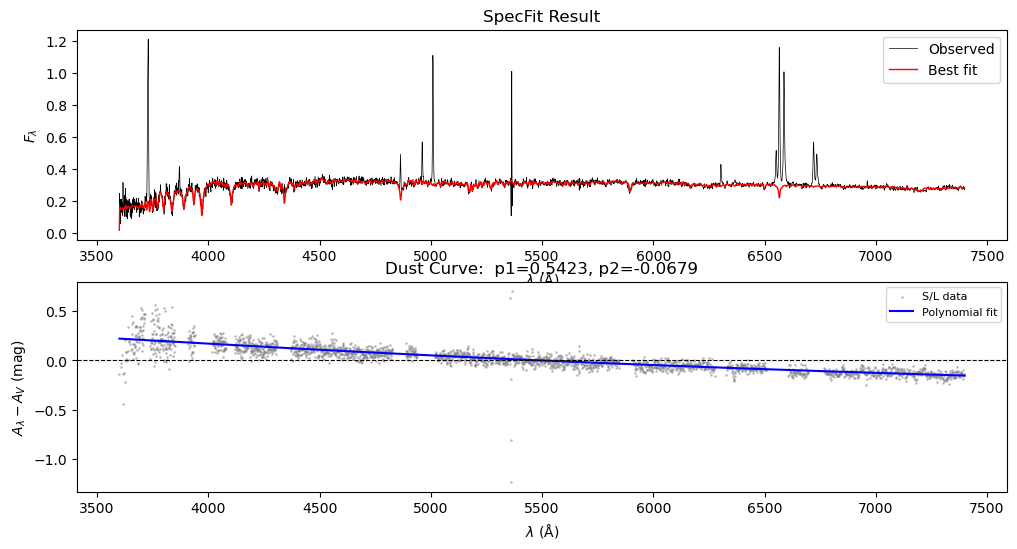

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
w = specfit.wave_prep
ax1.plot(w, specfit.flux_prep, "k-", lw=0.5, label="Observed")
if specfit.bestfit is not None:
    ax1.plot(w, specfit.bestfit, "r-", lw=1, label="Best fit")
ax1.set_xlabel(r"$\lambda\ (\mathrm{\AA})$"); ax1.set_ylabel(r"$F_\lambda$")
ax1.legend(); ax1.set_title("SpecFit Result")

w_dust = np.linspace(3600, 7400, 500)
x_dust = 10000.0 / w_dust
xv = 10000.0 / 5500.0
A_dust = specfit.p1 * (x_dust - xv) + specfit.p2 * (x_dust**2 - xv**2)
if specfit._dust_data_wave is not None:
    ax2.scatter(specfit._dust_data_wave, specfit._dust_data_A, s=1, c='gray', alpha=0.4,
                rasterized=True, label='S/L data')
ax2.plot(w_dust, A_dust, 'b-', lw=1.5, label='Polynomial fit')
ax2.axhline(0.0, color='k', ls='--', lw=0.8)
ax2.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
ax2.set_ylabel(r'$A_\lambda - A_V\ \mathrm{(mag)}$')
ax2.set_title(f'Dust Curve:  p1={specfit.p1:.4f}, p2={specfit.p2:.4f}')
ax2.legend(fontsize=8)


## 4. MCMC — Stellar Population Inference

In [14]:
mc = MCMCFitter(
    ssp_fits=SSP_FILE,
    specfit_result=specfit,
    sfh_model='delayed',
    wave_range=(3600, 7400),
)
print(f'Likelihood ndof = {mc.likelihood.ndof}')

Likelihood ndof = 2528


In [24]:
%%time
CHAIN_DIR = os.path.join(OUT_DIR, 'chains_manga-7443')
#CHAIN_DIR = os.path.join(OUT_DIR, 'chains_manga-8131')
N_LIVE = 400
mcmc_result = mc.run(n_live=N_LIVE, chain_dir=CHAIN_DIR, frac_remain=0.5)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+03  686.63 [-1688.3374..-1688.3346]*| it/evals=5200/20017 eff=26.5076% N=400  
[ultranest] Likelihood function evaluations: 20017
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -1700 +- 0.114
[ultranest] Effective samples strategy satisfied (ESS = 987.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.42, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.11 tail:0.40 total:0.42 required:<0.50
[ultranest] done iterating.

logZ = -1700.005 +- 0.494
  single instance: logZ = -1700.005 +- 0.165
  bootstrapped   : logZ = -1700.011 +- 0.283
  tail           : logZ = +- 0.405
insert order U test : converged: True correlation: inf iterations

    t0                  : 0.10  │▇▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁ ▁        ▁ │3.21      0.44 +- 0.32
    tau      

In [25]:
post  = mcmc_result.posterior
names = mc._sampler.param_names
best  = mcmc_result.bestfit

print(f'Posterior samples: {len(post)}')
print(f'log Z = {mcmc_result.log_evidence:.2f}')
for i, name in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    print(f'  {name:12s} = {med:8.4f}  [+{hi-med:.4f} / -{med-lo:.4f}]')
if 'logZsun' in best:
    Z = 0.02 * 10 ** best['logZsun']
    print(f'  Z = {Z:.5f}  (Z_solar = 0.02)')

Posterior samples: 5603
log Z = -1700.01
  t0           =   0.3484  [+0.3721 / -0.1907]
  tau          =   3.4262  [+0.0840 / -0.1232]
  logZsun      =  -0.9483  [+0.0247 / -0.0265]
  Z = 0.00225  (Z_solar = 0.02)


## 5. Visualization

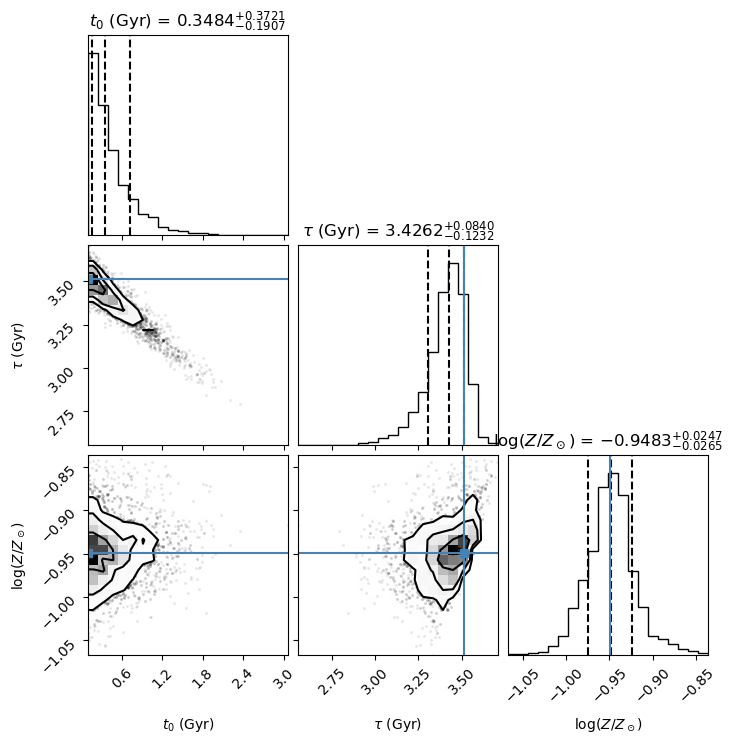

In [26]:
# 5a. Corner plot
from corner import corner as _corner
_label_map = {'logZsun': r'$\log(Z/Z_\odot)$',
              't0':      r'$t_0\ \mathrm{(Gyr)}$',
              'tau':     r'$\tau\ \mathrm{(Gyr)}$'}
labels = [_label_map.get(n, n) for n in names]
truths = [best[n] for n in names]

fig = _corner(post, labels=labels, truths=truths,
              quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.4f')
plt.show()

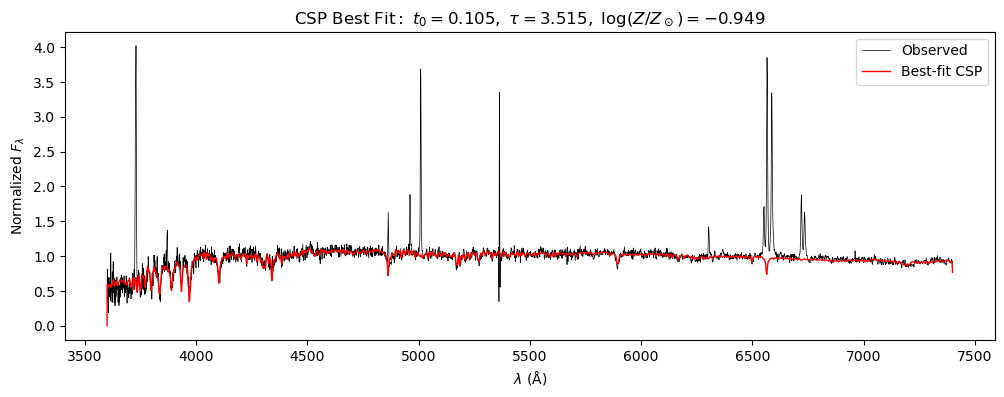

In [27]:
# 5b. Best-fit CSP
like = mc.likelihood
sfh_best = DelayedExponentialSFH(
    **{k: v for k, v in best.items() if k != 'logZsun'}, age_universe=13.8)
logZ = best.get('logZsun', 0.0)

csp = like.builder.build(logZ, sfh_best)
csp = like.broadener.apply(csp)
n = like._med5500(like.ssp.wave, csp, np.ones_like(csp, dtype=bool), like._n_range)
csp = csp / n; csp = like.dust.apply(csp)
csp_obs = np.interp(like.obs_wave, like.ssp.wave, csp, left=0.0, right=0.0)
n_obs = 1.0 / np.median(like.obs_flux[like.obs_mask])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(like.obs_wave, like.obs_flux * n_obs, 'k-', lw=0.5, label='Observed')
ax.plot(like.obs_wave, csp_obs * n_obs, 'r-', lw=1, label='Best-fit CSP')
ax.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
ax.set_ylabel(r'Normalized $F_\lambda$'); ax.legend()
_name_map = {'logZsun': r'\log(Z/Z_\odot)', 't0': 't_0', 'tau': r'\tau'}
tparts = [rf'${_name_map.get(k,k)}={v:.3f}$' for k, v in best.items()]
ax.set_title(r'$\mathrm{CSP\ Best\ Fit:}\ $' + r'$,\ $'.join(tparts))
plt.show()

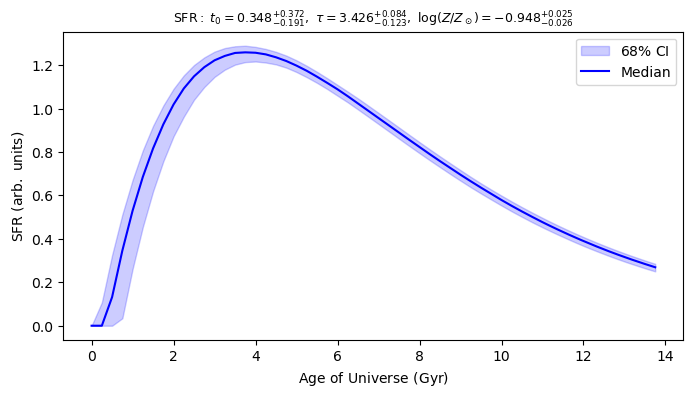

In [28]:
# 5c. SFH with 68% CI
cosmic_time = np.max(like.ssp.time) - like.ssp.time
n_use = min(300, len(post))
idx = np.random.choice(len(post), n_use, replace=False)
_sfh_idx = {n: i for i, n in enumerate(names) if n != 'logZsun'}

sfr_grid = np.zeros((n_use, len(cosmic_time)))
for k in range(n_use):
    kw = {n: post[idx[k], j] for n, j in _sfh_idx.items()}
    s = DelayedExponentialSFH(**kw, age_universe=13.8)
    sfr_grid[k] = s.evaluate(like.ssp.time)

sfr_lo  = np.percentile(sfr_grid, 16, axis=0)
sfr_med = np.percentile(sfr_grid, 50, axis=0)
sfr_hi  = np.percentile(sfr_grid, 84, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(cosmic_time, sfr_lo, sfr_hi, color='b', alpha=0.2, label=r'$68\%$ CI')
ax.plot(cosmic_time, sfr_med, 'b-', lw=1.5, label='Median')
ax.set_xlabel(r'$\mathrm{Age\ of\ Universe\ (Gyr)}$')
ax.set_ylabel(r'$\mathrm{SFR\ (arb.\ units)}$')
tparts_sfh = []
for i, n in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    lbl = _name_map.get(n, n)
    tparts_sfh.append(rf'${lbl} = {med:.3f}^{{+{hi-med:.3f}}}_{{-{med-lo:.3f}}}$')
ax.set_title(r'$\mathrm{SFR:}\ $' + r'$,\ $'.join(tparts_sfh), fontsize=9)
ax.legend(); plt.show()

## 6. Custom SFH — DelayTau (t0 ≡ 0)

In [38]:
class DelayTauSFH(SFHBase):
    """SFR(t) = t · exp(−t/τ), t₀ = 0,  free param: τ"""
    n_params = 1
    param_names = ['tau']
    default_priors = {'tau': LogUniformPrior(0.1, 10.0)}
    def __init__(self, tau, age_universe=13.8):
        self.tau = float(tau); self.age_universe = float(age_universe)
    def evaluate(self, timegrid):
        t = np.max(timegrid) - timegrid
        sfr = t * np.exp(-t / self.tau)
        sfr[timegrid > self.age_universe] = 0.0
        return sfr

print(f'Custom SFH: {DelayTauSFH.n_params} params: {DelayTauSFH.param_names}')

Custom SFH: 1 params: ['tau']


In [ ]:
%%time
mc_custom = MCMCFitter(
    ssp_fits=SSP_FILE, specfit_result=specfit,
    sfh_model=DelayTauSFH, wave_range=(3600, 7400),
)
chain_custom = os.path.join(OUT_DIR, 'chains_custom_sfh')
#chain_custom = os.path.join(OUT_DIR, 'chains_custom_sfh_8131')
res_custom = mc_custom.run(
    n_live=400, chain_dir=chain_custom,
    priors={'logZsun': UniformPrior(-2.5, 0.5), 'tau': LogUniformPrior(0.1, 10.0)},
)

pc = res_custom.posterior
print(f'Active params: {mc_custom._sampler.param_names}  (N={len(pc)})')
for i, n in enumerate(mc_custom._sampler.param_names):
    lo, med, hi = np.percentile(pc[:, i], [16, 50, 84])
    print(f'  {n:10s} = {med:.4f}  [{lo:.4f}, {hi:.4f}]')

dlogZ = res_custom.log_evidence - mcmc_result.log_evidence
print(f'\nΔlogZ (2p − 3p) = {dlogZ:.1f}')
print(f'({'>0' if dlogZ > 0 else '<0'}: DelayTau {'favored' if dlogZ > 0 else 'disfavored'} vs DelayedExp)')

[ultranest] Sampling 400 live points from prior ...


Z=-1698.2(12.27%) | Like=-1688.84..-1686.32 [-1688.8421..-1688.8361]*| it/evals=3505/5771 eff=65.2579% N=400 

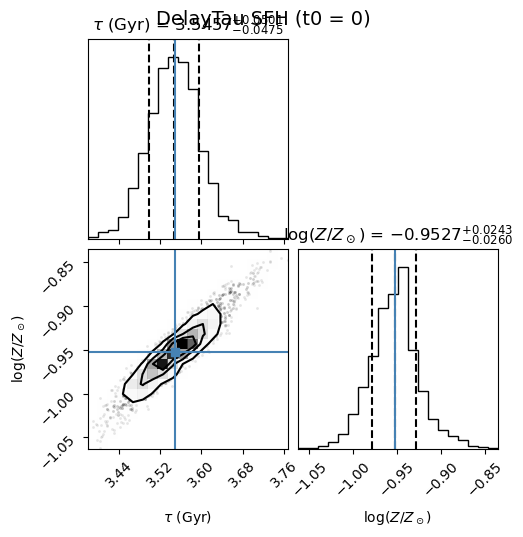

In [31]:
# Corner plot for custom SFH
names_c = mc_custom._sampler.param_names
_label_map_c = {'logZsun': r'$\log(Z/Z_\odot)$', 'tau': r'$\tau\ \mathrm{(Gyr)}$'}
labels_c = [_label_map_c.get(n, n) for n in names_c]
best_c = [res_custom.bestfit[n] for n in names_c]

fig = _corner(pc, labels=labels_c, truths=best_c,
              quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.4f')
fig.suptitle('DelayTau SFH (t0 = 0)', fontsize=14)
plt.show()

## 6b. Custom SFH — Double Power Law (3 params)

$$\mathrm{SFR}(t) = \frac{1}{(t/\tau)^\alpha + (t/\tau)^{-\beta}}$$\n
Parameters: τ (peak time), α (declining slope), β (rising slope)

In [ ]:
class DoublePowerLawSFH(SFHBase):
    """SFR(t) = 1 / ((t/τ)^α + (t/τ)^(−β)),   free params: τ, α, β"""
    n_params = 3
    param_names = ["tau", "alpha", "beta"]
    default_priors = {
        "tau":   LogUniformPrior(0.1, 13.0),
        "alpha": LogUniformPrior(0.1, 10.0),
        "beta":  LogUniformPrior(0.1, 10.0),
    }
    
    def __init__(self, tau, alpha, beta, age_universe=13.8):
        self.tau   = float(tau)
        self.alpha = float(alpha)
        self.beta  = float(beta)
        self.age_universe = float(age_universe)
    
    def evaluate(self, timegrid):
        t = np.max(timegrid) - timegrid  # cosmic time
        t = np.where(t <= 0, 1e-10, t)  # avoid division by zero
        x = t / self.tau
        sfr = 1.0 / (x**self.alpha + x**(-self.beta))
        sfr[timegrid > self.age_universe] = 0.0
        return sfr
    
    def __repr__(self):
        return f'DPL_SFH(τ={self.tau:.2f}, α={self.alpha:.2f}, β={self.beta:.2f})'

print(f'DPL SFH: {DoublePowerLawSFH.n_params} params: {DoublePowerLawSFH.param_names}')

### Quick test: 看一眼不同参数的 SFH 形状

In [ ]:
# 快速测试不同参数的 SFH 形状
timegrid = np.linspace(0, 13.8, 200)
cosmic_time = np.max(timegrid) - timegrid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Varying τ
for tau in [1.0, 4.0, 10.0]:
    s = DoublePowerLawSFH(tau=tau, alpha=3.0, beta=3.0)
    axes[0].plot(cosmic_time, s.evaluate(timegrid), label=f'τ={tau}')
axes[0].set_xlabel('Age of Universe (Gyr)'); axes[0].set_ylabel('SFR')
axes[0].set_title('Varying τ (α=3, β=3)'); axes[0].legend()

# Varying α
for alpha in [1.0, 3.0, 5.0]:
    s = DoublePowerLawSFH(tau=4.0, alpha=alpha, beta=3.0)
    axes[1].plot(cosmic_time, s.evaluate(timegrid), label=f'α={alpha}')
axes[1].set_xlabel('Age of Universe (Gyr)'); axes[1].set_ylabel('SFR')
axes[1].set_title('Varying α (τ=4, β=3)'); axes[1].legend()

# Varying β
for beta in [1.0, 3.0, 5.0]:
    s = DoublePowerLawSFH(tau=4.0, alpha=3.0, beta=beta)
    axes[2].plot(cosmic_time, s.evaluate(timegrid), label=f'β={beta}')
axes[2].set_xlabel('Age of Universe (Gyr)'); axes[2].set_ylabel('SFR')
axes[2].set_title('Varying β (τ=4, α=3)'); axes[2].legend()

plt.tight_layout(); plt.show()

### Run MCMC with DPL SFH

In [ ]:
%%time
mc_dpl = MCMCFitter(
    ssp_fits=SSP_FILE, specfit_result=specfit,
    sfh_model=DoublePowerLawSFH, wave_range=(3600, 7400),
)
chain_dpl = os.path.join(OUT_DIR, 'chains_dpl')
res_dpl = mc_dpl.run(
    n_live=400, chain_dir=chain_dpl,
    priors={
        'logZsun': UniformPrior(-2.5, 0.5),
        'tau':     LogUniformPrior(0.1, 13.0),
        'alpha':   LogUniformPrior(0.1, 10.0),
        'beta':    LogUniformPrior(0.1, 10.0),
    },
)

pd = res_dpl.posterior
print(f'Active params: {mc_dpl._sampler.param_names}  (N={len(pd)})')
for i, n in enumerate(mc_dpl._sampler.param_names):
    lo, med, hi = np.percentile(pd[:, i], [16, 50, 84])
    print(f'  {n:10s} = {med:.4f}  [{lo:.4f}, {hi:.4f}]')
print(f'\nlog Z = {res_dpl.log_evidence:.2f}')

In [ ]:
# Corner plot for DPL
names_d = mc_dpl._sampler.param_names
_label_map_d = {'logZsun': r'$\log(Z/Z_\odot)$', 'tau': r'$\tau$ (Gyr)',
                'alpha': r'$\alpha$', 'beta': r'$\beta$'}
labels_d = [_label_map_d.get(n, n) for n in names_d]
best_d = [res_dpl.bestfit[n] for n in names_d]

fig = _corner(pd, labels=labels_d, truths=best_d,
              quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.4f')
fig.suptitle('Double Power Law SFH', fontsize=14)
plt.show()

### Model Comparison

In [ ]:
print(f'{"Model":<20s}  {"N_params":>8s}  {"log Z":>10s}  {"ΔlogZ":>8s}')
print('-' * 52)
models = [
    ('DelayedExp', 3, mcmc_result.log_evidence),
    ('DelayTau',   2, res_custom.log_evidence),
    ('DPL',        4, res_dpl.log_evidence),
]
for name, np_, lz in models:
    dlz = lz - mcmc_result.log_evidence
    print(f'{name:<20s}  {np_:>8d}  {lz:>10.2f}  {dlz:>+8.1f}')

## 7. Save Results

In [32]:
specfit.save(os.path.join(OUT_DIR, 'specfit_result.fits'))
mcmc_result.save_result(os.path.join(OUT_DIR, 'mcmc_bestfit.fits'))
np.save(os.path.join(OUT_DIR, 'posterior_samples.npy'), post)

print('Files saved to', OUT_DIR)
for f in ['specfit_result.fits', 'mcmc_bestfit.fits', 'posterior_samples.npy']:
    print(f'  {os.path.join(OUT_DIR, f)}')

Files saved to /home/chengz/Code/opencode/bigs_v2/out_notebook
  /home/chengz/Code/opencode/bigs_v2/out_notebook/specfit_result.fits
  /home/chengz/Code/opencode/bigs_v2/out_notebook/mcmc_bestfit.fits
  /home/chengz/Code/opencode/bigs_v2/out_notebook/posterior_samples.npy
